In [ ]:
%%capture --no-stderr
%pip install -quit -U langchain_openai langchain_core langgraph langgraph-supervisor

In [ ]:
%pip install --upgrade langchain langgraph langgraph-supervisor

In [ ]:
%pip install langchain-groq

In [5]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GROQ_API_KEY")
# _set_env("OPENAI_API_KEY")

In [10]:
import datetime
# from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
# from langchain.agents import create_react_agent
from langgraph.prebuilt import create_react_agent
# from langchain.agents import create_agent

# llm = ChatOpenAI(model="gpt-4o")


# llm = ChatOpenAI(model="gpt-4o")
llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

def currentdatetime() -> str:
    "This tool provides the current date, time and day of the week in your location."
    
    dt = datetime.datetime.now()
    return "Datetime is {} and today is {}".format(dt, dt.strftime('%A'))
            

time_keeper_agent = create_react_agent(
    model=llm,
    tools=[currentdatetime],
    name = "time_keeper_agent",
    prompt = "You tell the current date, time and day of the week in your location."
)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20636\4095548615.py:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  time_keeper_agent = create_react_agent(


In [11]:
def shopopeninghours() -> str:
    "This tool provides the daily shop's operating hours."
    schedule = """Monday 10:00am to 08:00pm
                  Tuesday 10:00am to 08:00pm
                  Wednesday 10:00am to 08:00pm
                  Thursday 10:00am to 08:00pm
                  Friday 10:00am to 08:00pm
                  Saturday 03:00pm to 05:00pm
                  Sunday 1:00pm to 06:00pm"""
    return schedule

schedule_keeper_agent = create_react_agent(
    model=llm,
    tools=[shopopeninghours],
    name = "schedule_keeper_agent",
    prompt = "You tell the shop's operating hours for each day in a week."
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20636\2489734674.py:12: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  schedule_keeper_agent = create_react_agent(


In [15]:
from langgraph_supervisor import create_supervisor

prompt = ("""You are a team supervisor to manage time_keeper_agent and schedule_keeper_agent 
          Your job is to respond to shop opening hour queries using time_keeper_agent and schedule_keeper_agent. 
          To get the current time and date use time_keeper_agent and 
          for getting shop's operating hours use schedule_keeper_agent
          You can use both agents in parallel to get required information.""") 

workflow = create_supervisor(
    [schedule_keeper_agent, time_keeper_agent],
    model= llm,
    output_mode = "full_history",
    prompt = prompt
)

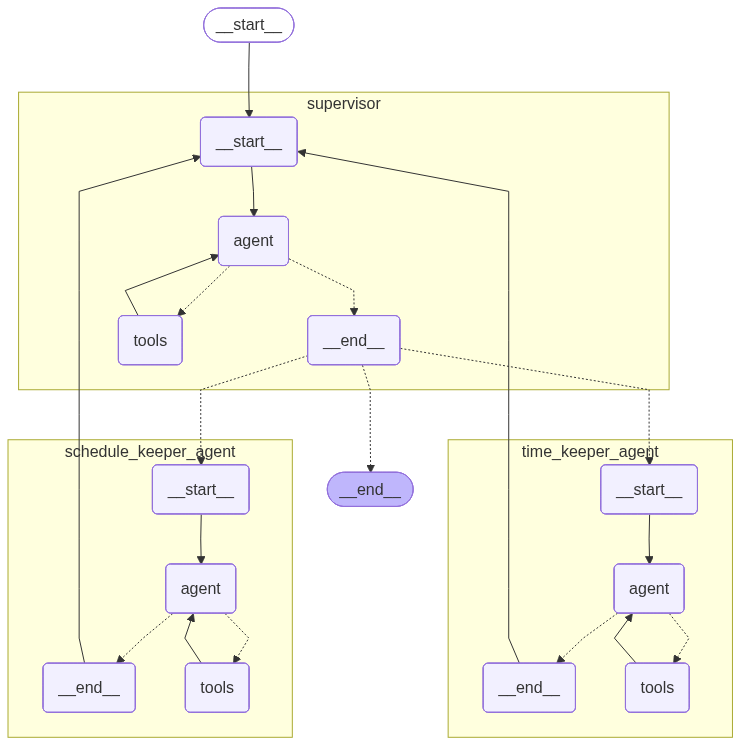

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: attempted to call tool 'transfer_back_to_supervisor' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=transfer_back_to_supervisor>{}</function>'}}

In [27]:
from IPython.display import Image, display

app = workflow.compile()

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

result = app.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What are the shop's opening hours on the weekend? Is the shop open right now?"
        }
    ]
})

for m in result['messages']:
    m.pretty_print()